### Chapter 2, Section 1: Secant and Tangent 
- This interactively demonstrates Example 1 on pages 78-79.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Secant Line: Definition and Origin
<table>
  <tr>
    <td style="vertical-align:top; width:50%;">

A **secant line** is a classical geometric concept.  

**Definition:**

A secant line is a line that **intersects a curve at two distinct points**.
    </td>
    <td style="vertical-align:top; text-align:right;">
      <img src="geo.png" style="max-width:772px;">
    </td>
  </tr>
</table>

## Secant in algebra
<table>
  <tr>
    <td style="vertical-align:top; width:50%;">

In algebra, when the curve is the graph of a function $y = f(x)$, the secant line through the points:

- $(a, f(a))$
- $(b, f(b))$

has slope:

$$
\frac{f(b) - f(a)}{b - a}
$$
$ $
    </td>
    <td style="vertical-align:top; text-align:right;">
      <img src="secant-line.png" style="max-width:772px;">
    </td>
  </tr>
</table>

interactive(children=(FloatSlider(value=2.0, description='Q - P (h)', max=2.0, min=-3.0, step=0.05), Output())…

<function __main__.plot_secant(h=2.0)>

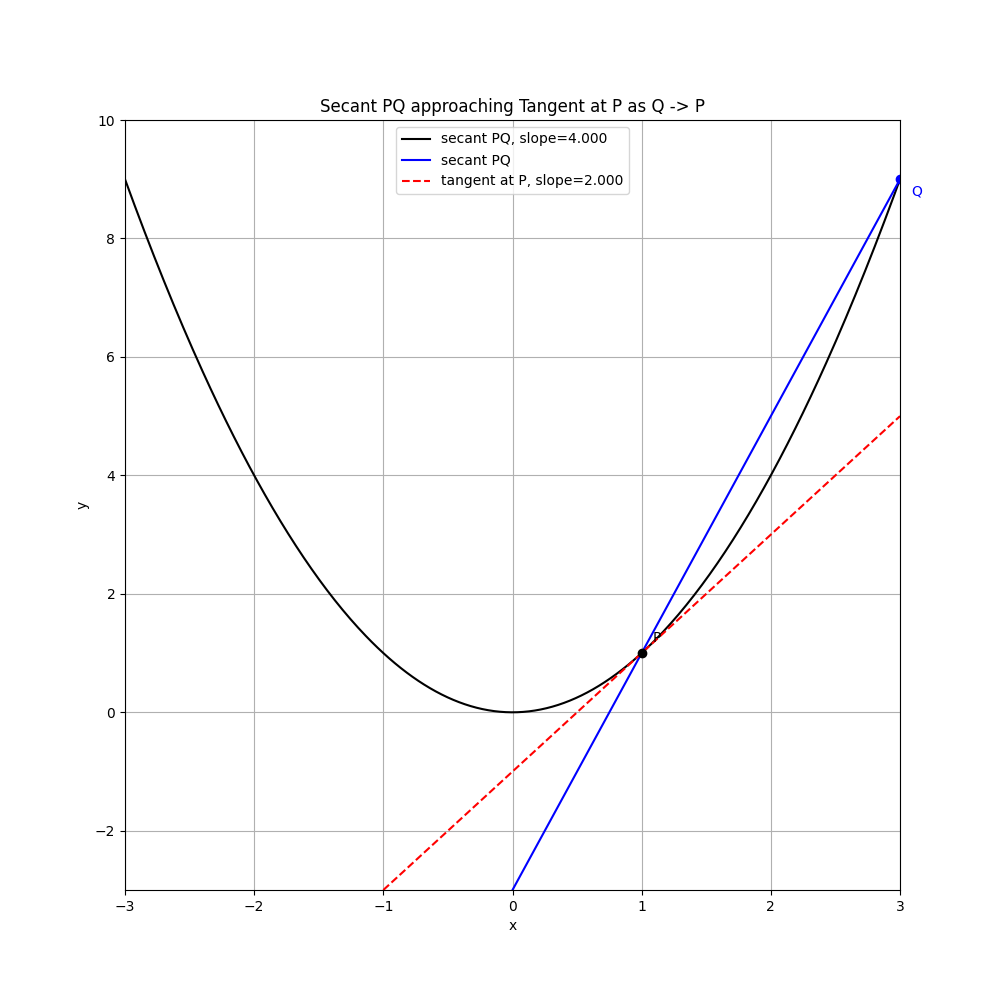

In [2]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display

# f(x) = x^2, fixed point P, and Q sliding toward P from either side
def f(x):
    return x**2

def df(x):
    return 2*x

P = 1.0
x = np.linspace(-3, 3, 400)

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(x, f(x), color='black', label='f(x) = x^2')

secant_line, = ax.plot([], [], color='blue', linewidth=1.5, label='secant PQ')
q_point, = ax.plot([], [], 'bo')
q_label = ax.annotate('Q', (0, 0), textcoords="offset points", xytext=(8, -12), color='blue')

m_tangent = df(P)
x_tan = np.linspace(P - 2, P + 2, 10)
ax.plot(x_tan, m_tangent * (x_tan - P) + f(P), color='red', linewidth=1.5,
        linestyle='--', label=f'tangent at P, slope={m_tangent:.3f}')

ax.plot(P, f(P), 'ko')
ax.annotate('P', (P, f(P)), textcoords="offset points", xytext=(8, 8), color='black')

ax.set_title('Secant PQ approaching Tangent at P as Q -> P')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 10)
ax.grid(True)
legend = ax.legend(loc='upper center')

def plot_secant(h=2.0):
    Q = P + h  # h > 0 -> Q approaches P from the right, h < 0 -> from the left

    if abs(h) > 1e-9:
        m_secant = (f(Q) - f(P)) / (Q - P)
        x_sec = np.linspace(min(P, Q) - 1, max(P, Q) + 1, 10)
        y_sec = m_secant * (x_sec - P) + f(P)
        secant_line.set_data(x_sec, y_sec)
        secant_line.set_label(f'secant PQ, slope={m_secant:.3f}')
        q_point.set_data([Q], [f(Q)])
        q_label.set_position((8, -12))
        q_label.xy = (Q, f(Q))
    else:
        secant_line.set_data([], [])
        q_point.set_data([], [])
        q_label.xy = (P, f(P))

    legend_texts = legend.get_texts()
    legend_texts[0].set_text(secant_line.get_label())
    fig.canvas.draw_idle()

# Slider: h is the signed distance from P to Q.
# Positive h -> Q approaches P from the right; 
# Negative h -> from the left.
widgets.interact(
    plot_secant,
    h=widgets.FloatSlider(value=2.0, min=-3.0, max=2.0, step=0.05,
                           description='Q - P (h)', continuous_update=True)
)


## Algebraic slope of line $PQ$ on $f(x) = x^2$

For the parabola

$$
f(x)=x^2,
$$

let $x$ be any real number. The point on the parabola is

$$
Q=(x,f(x))=(x,x^2).
$$

So the slope of line $PQ$ where $P(1,1)$

$$
m_{PQ} = \frac{x^2 - 1 }{ x - 1}
$$


So the tangent line at $P=(1,1)$ is

$$
y-1=2(x-1),
$$

or, 

$$
{y=2x-1}.
$$

In [3]:
# Slope of f(x) = x^2 at P by secant slopes approaching P
h_values = np.array([1.0, 0.5, 0.1, 0.01, 0.001, 0.000001])
secant_slopes = (f(P + h_values) - f(P)) / h_values

print("P =", (P, f(P)))
for h, slope in zip(h_values, secant_slopes):
    print(f"h = {h:>4.2f}, secant slope = {slope:.4f}")

P = (1.0, 1.0)
h = 1.00, secant slope = 3.0000
h = 0.50, secant slope = 2.5000
h = 0.10, secant slope = 2.1000
h = 0.01, secant slope = 2.0100
h = 0.00, secant slope = 2.0010
h = 0.00, secant slope = 2.0000
